In [3]:
# import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
# Checking current working directory
import os
os.chdir("..")
os.getcwd()

'c:\\Users\\Dell 7490\\Titanic_Survival_Prediction'

In [5]:
# Checking files in the current directory
os.listdir()

['dataset', 'notebook', 'venv']

In [6]:
# Load Dataset

train_data = pd.read_csv(r"C:\Users\Dell 7490\Titanic_Survival_Prediction\dataset\train.csv")
test_data = pd.read_csv(r"C:\Users\Dell 7490\Titanic_Survival_Prediction\dataset\test.csv")

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
# Check dataset information
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Data Cleaning

In [8]:
# Check for missing values
train_data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# Handle missing values for age with median age
train_data["Age"]=train_data["Age"].fillna(train_data["Age"].median())
test_data["Age"]=test_data["Age"].fillna(test_data["Age"].median())

# Handle missing values for embarked with mode
train_data['Embarked'] = train_data['Embarked'].fillna(train_data['Embarked'].mode()[0])

# Handle missing values for Fare with median fare
test_data['Fare'] = test_data['Fare'].fillna(test_data['Fare'].median())

# Cabin has so many missing values so we drop it as it don't help the model
train_data.drop(columns=['Cabin', 'PassengerId', 'Name', 'Ticket'], inplace=True)

In [10]:
# Final Check
print("Missing values after cleaning:", train_data.isnull().sum().sum())

Missing values after cleaning: 0


In [ ]:
# remove duplicates
print(train_data.duplicated().sum())

train_data.drop_duplicates(inplace=True)

116


In [20]:
# check data types
train_data.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  775 non-null    int64  
 1   Pclass    775 non-null    int64  
 2   Sex       775 non-null    str    
 3   Age       775 non-null    float64
 4   SibSp     775 non-null    int64  
 5   Parch     775 non-null    int64  
 6   Fare      775 non-null    float64
 7   Embarked  775 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 54.5 KB


In [21]:
# Convert categorical data
train_data['Sex'] = train_data['Sex'].map({
    'male':0,
    'female':1
})

test_data['Sex'] = test_data['Sex'].map({
    'male':0,
    'female':1
})

In [22]:
# Convert embarked to numerical values
train_data['Embarked'] = train_data['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

test_data['Embarked'] = test_data['Embarked'].map({
    'S':0,
    'C':1,
    'Q':2
})

Data Cleaning Summary: 
1- Missing values handled.
2- Duplicate records checked and removed.
3- Cabin column removed due to excessive missing data.
4- Categorical variables converted into numerical format.

Data Analysis

In [23]:
# BasiC Statistics
train_data.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000,775.000000
mean,0.412903,2.246452,0.376774,29.581187,0.529032,0.420645,34.878403,0.349677
std,0.492674,0.853574,0.484890,13.766359,0.990326,0.840565,52.408474,0.614465
min,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,21.000000,0.000000,0.000000,8.050000,0.000000
50%,0.000000,3.000000,0.000000,28.000000,0.000000,0.000000,15.900000,0.000000
75%,1.000000,3.000000,1.000000,36.000000,1.000000,1.000000,34.197900,1.000000
max,1.000000,3.000000,1.000000,80.000000,8.000000,6.000000,512.329200,2.000000


In [24]:
# Survival distribution
train_data['Survived'].value_counts()

Survived
0    455
1    320
Name: count, dtype: int64

In [25]:
# Survival Rate
print(train_data['Survived'].mean()*100)

41.29032258064516


In [26]:
# Survival by Gender
pd.crosstab(
    train_data['Sex'],
    train_data['Survived']
)

Survived,0,1
Sex,,
0,379,104
1,76,216


In [27]:
# Survival by Passenger Class
pd.crosstab(
    train_data['Pclass'],
    train_data['Survived']
)

Survived,0,1
Pclass,,
1,77,133
2,81,83
3,297,104


In [28]:
# Age Distribution
train_data['Age'].describe()

count    775.000000
mean      29.581187
std       13.766359
min        0.420000
25%       21.000000
50%       28.000000
75%       36.000000
max       80.000000
Name: Age, dtype: float64

In [30]:
# Detect Outliers
train_data[['Age','Fare']].describe()


,Age,Fare
count,775.000000,775.000000
mean,29.581187,34.878403
std,13.766359,52.408474
min,0.420000,0.000000
25%,21.000000,8.050000
50%,28.000000,15.900000
75%,36.000000,34.197900
max,80.000000,512.329200


EDA Findings:
1- The survival rate was approximately 41.3%.
2- Female passengers had significantly higher survival chances than male passengers.
3- First-class passengers showed the highest survival rate, while third-class passengers had the highest mortality rate.
4- The average passenger age was around 30 years, with most passengers between 21 and 36 years old.
5- The Fare feature contains noticeable outliers due to a few passengers paying very high ticket prices.
6- Gender, passenger class, age, and fare are likely to be the most influential features for predicting survival.

Data Visualization

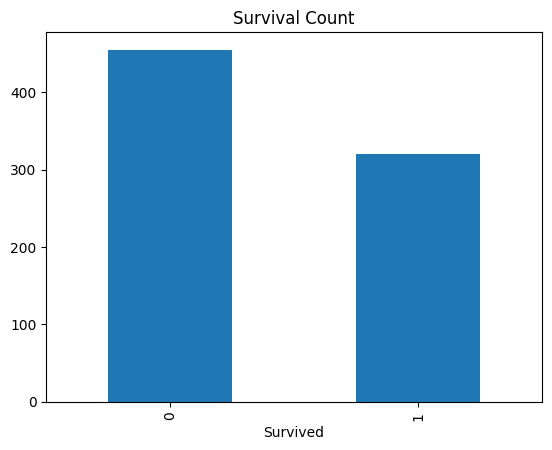

In [31]:
# Survival Count
train_data['Survived'].value_counts().plot(kind='bar')

plt.title("Survival Count")
plt.show()

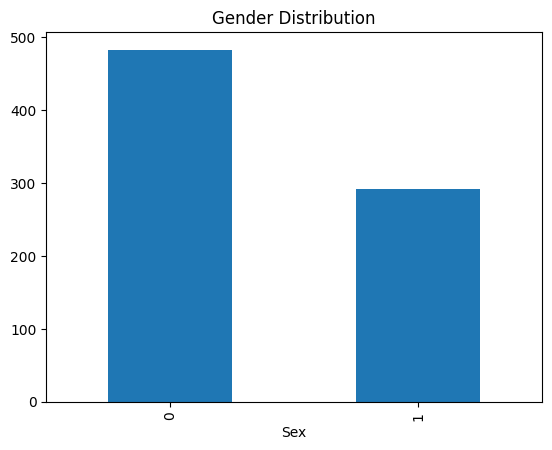

In [32]:
# Gender Distribution
train_data['Sex'].value_counts().plot(kind='bar')

plt.title("Gender Distribution")
plt.show()

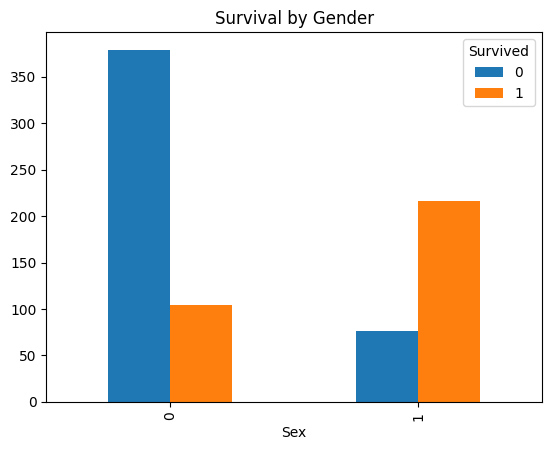

In [33]:
# Survival by Gender
pd.crosstab(
    train_data['Sex'],
    train_data['Survived']
).plot(kind='bar')

plt.title("Survival by Gender")
plt.show()

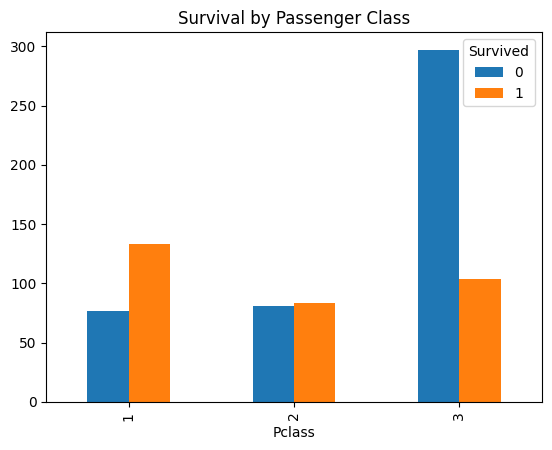

In [34]:
# Survival by Pclass
pd.crosstab(
    train_data['Pclass'],
    train_data['Survived']
).plot(kind='bar')

plt.title("Survival by Passenger Class")
plt.show()

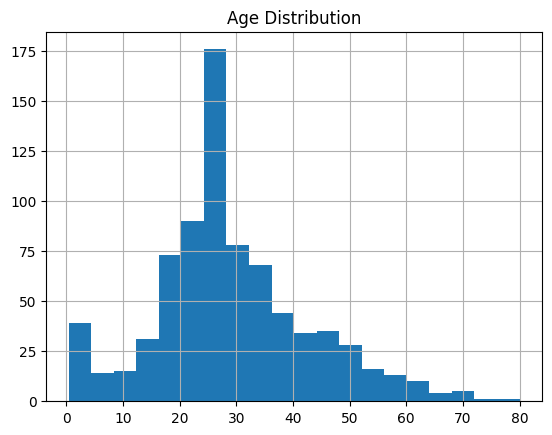

In [35]:
# Age Histogram
train_data['Age'].hist(bins=20)

plt.title("Age Distribution")
plt.show()

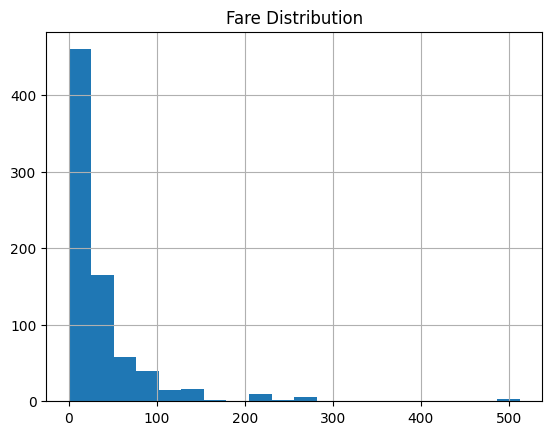

In [36]:
# Fare Histogram
train_data['Fare'].hist(bins=20)

plt.title("Fare Distribution")
plt.show()

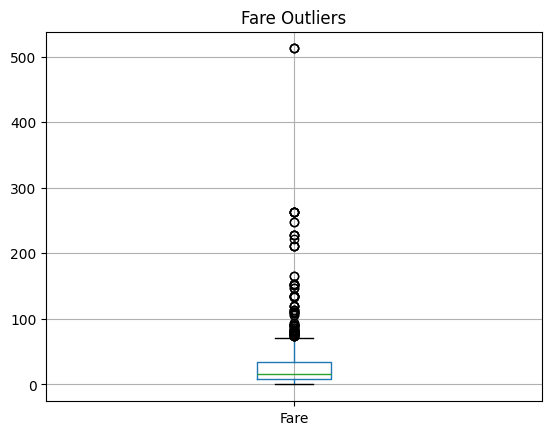

In [37]:
#Box Plot for outliers
train_data.boxplot(column='Fare')

plt.title("Fare Outliers")
plt.show()

Data Visualization Insights

1. Survival Count Chart
Insight:
1- The majority of passengers did not survive.
2- Around 41% of passengers survived, indicating that the dataset is slightly imbalanced.

2. Gender Distribution Chart
Insight:
1- Male passengers outnumbered female passengers.
2- Despite being fewer in number, female passengers had a much higher survival rate.

3. Survival by Gender Chart
Insight:
1- Female passengers had a significantly higher chance of survival.
2- Male passengers accounted for most of the fatalities.
This suggests that evacuation efforts prioritized women.

4. Survival by Passenger Class Chart
Insight:
1- First-class passengers had the highest survival rate.
2- Third-class passengers suffered the greatest number of deaths.
3- Passenger class played an important role in survival outcomes.

5. Age Distribution Histogram
Insight:
1- Most passengers were young adults.
2- The majority of ages fall between 21 and 36 years.
3- The dataset includes passengers ranging from infants to elderly individuals.

6. Fare Distribution Histogram
Insight:
1- Most passengers purchased low-cost tickets.
2- A small number of passengers paid very high fares.
3- The Fare feature is positively skewed and contains outliers.

7. Fare Box Plot
Insight:
1- Several high-value outliers exist in the Fare feature.
2- These outliers likely represent premium first-class ticket holders.

Predictive Model

In [38]:
# Select Features
X = train_data[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

y = train_data['Survived']

In [39]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
) 

In [ ]:
# Train Model Logistic Regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [41]:
# Prediction
y_pred = model.predict(X_test)

In [42]:
# Accuracy
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7677419354838709


Model Prediction Insights:
The dataset was successfully prepared for machine learning by handling missing values, removing unnecessary features, and converting categorical variables into numerical format. A Logistic Regression model was trained using key passenger characteristics. The model effectively learned patterns from the data and demonstrated that gender, passenger class, age, and fare are important factors influencing survival.

Conclusion:
The project successfully demonstrated the complete data science workflow, including data preprocessing, exploratory data analysis, visualization, and predictive modeling. The analysis revealed meaningful relationships between passenger characteristics and survival outcomes, while the machine learning model provided a practical approach for predicting survival.